# Notebook 1 — Data setup

This series answers one question: **which sales-rep activities (CRM usage, calls, demos, ...) actually help sales results, and which just look like they do?**

We focus strictly on *activities*, not on ranking or typing individual reps. For each activity we'll always ask the same thing: does the level of this activity relate to revenue, and — separately — does it *cause* revenue?

To teach that distinction honestly, this notebook **simulates** the dataset the rest of the series uses, with a known ground truth baked in:

| Activity | True relationship to revenue |
|---|---|
| `demos_given` | **Causal** — really moves revenue |
| `proposals_sent` | **Causal** — really moves revenue |
| `crm_usage` | **Confounded** — correlates with revenue only because both are driven by territory quality; using the CRM more does *not* itself raise revenue |
| `calls_made` | **Reverse-causal** — reps who already have strong pipelines naturally make more calls; the calls are a symptom, not a cause |
| `training_completed` | **Pure noise** — no relationship to anything |

With real data you never get to know this table — you only ever see the numbers and have to *infer* the mechanism. Here we get to check our later inferences (notebooks 2–5) against the actual truth, because we wrote the truth ourselves. Notebooks 2–4 will proceed as if this table doesn't exist; notebook 5 reveals it for a direct comparison.

Output of this notebook:
- `data/sales_activity_data.csv` — the "public" dataset later notebooks work from
- `data/ground_truth.json` — the answer key, opened only in notebook 5

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", rc={"grid.color": "#e6e5e0", "axes.edgecolor": "#c9c8c0"})
ACCENT = "#2a78d6"  # one hue throughout — each panel is already labeled by activity name, so color carries no extra identity here

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
N_REPS = 400

DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

## The hidden confounder: territory quality

Before any activity, each rep is assigned a territory (accounts, region, lead quality). Some territories are simply better than others — bigger accounts, warmer leads — independent of anything the rep does.

`territory_z` below is that latent quality, standardized (mean 0, sd 1). We'll also store a friendlier rescaled version, `territory_score` (1–10), in the public dataset — this is realistic: companies really do track a territory/account tier. What later notebooks *won't* have is the knowledge that this variable is the true source of `crm_usage`'s correlation with revenue.

In [2]:
territory_z = rng.normal(0, 1, N_REPS)
territory_score = np.clip(5 + 2 * territory_z, 1, 10).round(1)

## The activities

`demos_given`, `proposals_sent`, and `training_completed` are drawn independently of territory — they reflect what the rep chooses to do, not what they were handed. `crm_usage` is drawn **from** territory (bigger territories mean more accounts to log), which is exactly what makes it a confound rather than a driver.

In [3]:
demos_given = rng.poisson(6, N_REPS)
proposals_sent = rng.poisson(4, N_REPS)
training_completed = rng.poisson(2, N_REPS)

crm_lambda = np.clip(8 + 6 * territory_z, 0.5, None)  # better territory -> more accounts -> more CRM logging
crm_usage = rng.poisson(crm_lambda)

## Revenue: the ground-truth formula

Revenue is generated from an intercept plus **only** `demos_given`, `proposals_sent`, and `territory_z`, plus noise. `crm_usage` and `training_completed` never enter this formula — any correlation they show later is either indirect (via territory) or pure chance.

`quota_hit` is just revenue thresholded, giving us a binary outcome to work with alongside the continuous one.

In [4]:
INTERCEPT = 20_000
TRUE_BETA_DEMOS = 1500        # $ per demo given        -> causal
TRUE_BETA_PROPOSALS = 2500    # $ per proposal sent      -> causal
TRUE_BETA_TERRITORY = 8000    # $ per unit of territory_z -> the confound's real driver
NOISE_SD = 5000
QUOTA_THRESHOLD = 40_000

noise = rng.normal(0, NOISE_SD, N_REPS)
revenue = (
    INTERCEPT
    + TRUE_BETA_DEMOS * demos_given
    + TRUE_BETA_PROPOSALS * proposals_sent
    + TRUE_BETA_TERRITORY * territory_z
    + noise
)
revenue = np.clip(revenue, 0, None).round(2)
quota_hit = (revenue > QUOTA_THRESHOLD).astype(int)

# calls_made is computed FROM revenue, and never feeds back into it above —
# a clean case of reverse causation: revenue causes calls, not the other way round.
calls_made = np.clip(15 + 0.00035 * revenue + rng.normal(0, 9, N_REPS), 0, None).round().astype(int)

## Assemble the dataset

`territory_score` is kept in the public table — a real analyst would normally have it too. What stays hidden is *which* activities the formula above actually used.

In [5]:
activity_cols = ["demos_given", "proposals_sent", "crm_usage", "calls_made", "training_completed"]

df = pd.DataFrame({
    "rep_id": [f"REP{i:04d}" for i in range(1, N_REPS + 1)],
    "territory_score": territory_score,
    "demos_given": demos_given,
    "proposals_sent": proposals_sent,
    "crm_usage": crm_usage,
    "calls_made": calls_made,
    "training_completed": training_completed,
    "revenue": revenue,
    "quota_hit": quota_hit,
})
df.head()

,rep_id,territory_score,demos_given,proposals_sent,crm_usage,calls_made,training_completed,revenue,quota_hit
0,REP0001,5.6,5,1,10,33,1,34080.66,0
1,REP0002,2.9,1,4,1,27,1,20011.97,0
2,REP0003,6.5,8,3,21,25,3,47631.93,1
3,REP0004,6.9,3,4,13,17,0,36598.13,0
4,REP0005,1.1,7,4,0,25,1,28062.03,0


## Sanity check

Just a visual look before any statistics — do the distributions look plausible, and does anything jump out in the raw scatter against revenue? (The real analysis starts in notebook 2.)

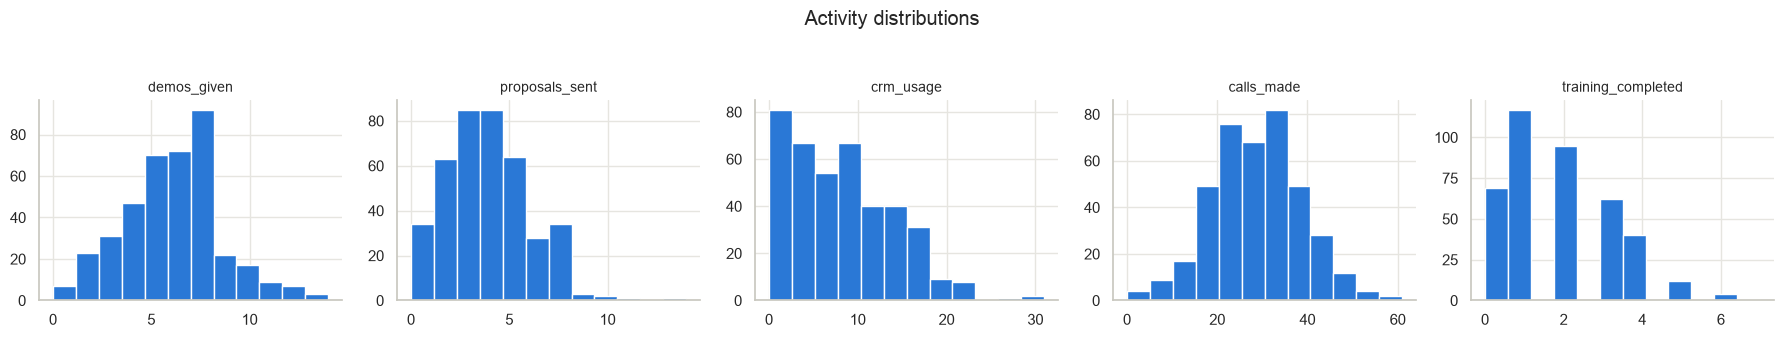

In [6]:
fig, axes = plt.subplots(1, len(activity_cols), figsize=(18, 3.2))
for ax, col in zip(axes, activity_cols):
    ax.hist(df[col], bins=12, color=ACCENT, edgecolor="white")
    ax.set_title(col, fontsize=10)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
fig.suptitle("Activity distributions", y=1.05)
plt.tight_layout()
plt.show()

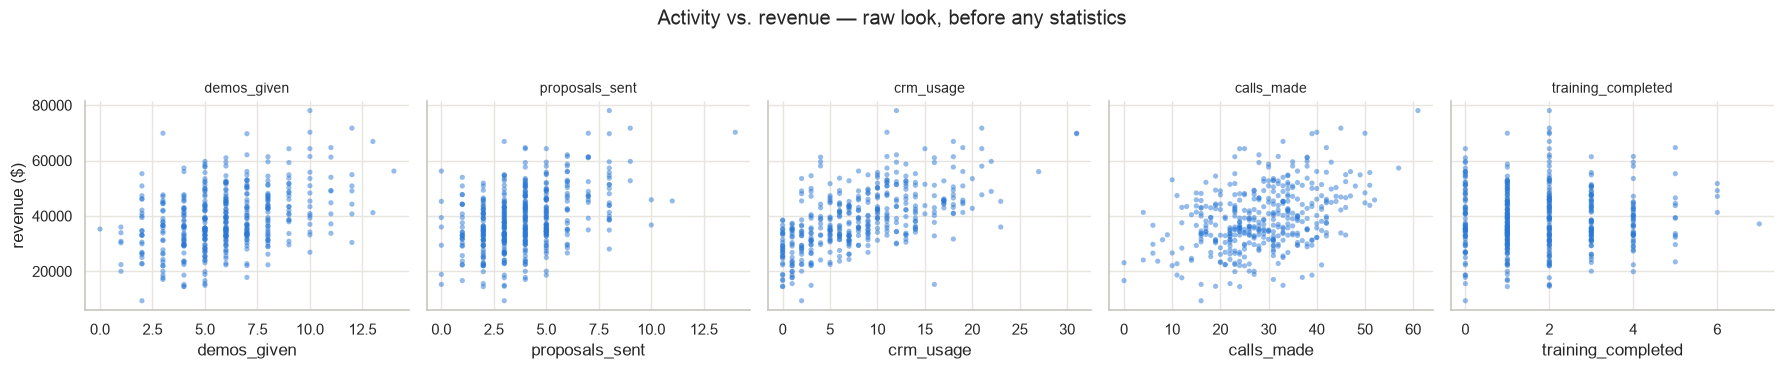

In [7]:
fig, axes = plt.subplots(1, len(activity_cols), figsize=(18, 3.5), sharey=True)
for ax, col in zip(axes, activity_cols):
    ax.scatter(df[col], df["revenue"], s=14, alpha=0.5, color=ACCENT, edgecolor="none")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(col)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel("revenue ($)")
fig.suptitle("Activity vs. revenue — raw look, before any statistics", y=1.05)
plt.tight_layout()
plt.show()

## Save: public dataset vs. answer key

Two files, deliberately kept separate:

- **`sales_activity_data.csv`** — what an analyst normally has. Notebooks 2–4 use only this.
- **`ground_truth.json`** — the generating coefficients and true relationship type per activity. Opened only in notebook 5, to compare naive correlation and adjusted/causal estimates against the truth we actually built in.

In [6]:
public_cols = ["rep_id", "territory_score"] + activity_cols + ["revenue", "quota_hit"]
df[public_cols].to_csv(DATA_DIR / "sales_activity_data.csv", index=False)

ground_truth = {
    "random_seed": RANDOM_SEED,
    "n_reps": N_REPS,
    "revenue_model": {
        "intercept": INTERCEPT,
        "noise_sd": NOISE_SD,
        "quota_threshold": QUOTA_THRESHOLD,
    },
    "activities": {
        "demos_given": {
            "relationship": "causal",
            "true_effect_per_unit": TRUE_BETA_DEMOS,
            "mechanism": "Directly adds to revenue in the generating formula.",
        },
        "proposals_sent": {
            "relationship": "causal",
            "true_effect_per_unit": TRUE_BETA_PROPOSALS,
            "mechanism": "Directly adds to revenue in the generating formula.",
        },
        "crm_usage": {
            "relationship": "confounded",
            "true_effect_per_unit": 0,
            "mechanism": "Driven by territory_z (better territories mean more accounts to log). Territory also independently drives revenue, so crm_usage correlates with revenue without causing it.",
        },
        "calls_made": {
            "relationship": "reverse_causal",
            "true_effect_per_unit": 0,
            "mechanism": "Computed FROM revenue (reps with stronger pipelines naturally make more calls). Revenue causes calls_made, not the other way around.",
        },
        "training_completed": {
            "relationship": "noise",
            "true_effect_per_unit": 0,
            "mechanism": "Drawn independently of everything else. No relationship to revenue.",
        },
    },
    "confounder": {
        "name": "territory_score",
        "true_effect_per_unit_z": TRUE_BETA_TERRITORY,
        "note": "territory_z (standardized, mean 0 sd 1) is the actual generating variable. The public dataset stores territory_score = clip(5 + 2*territory_z, 1, 10); recover it approximately with territory_z = (territory_score - 5) / 2.",
    },
}

with open(DATA_DIR / "ground_truth.json", "w") as f:
    json.dump(ground_truth, f, indent=2)

print(f"Saved {len(df)} rows to {DATA_DIR / 'sales_activity_data.csv'}")
print(f"Saved answer key to {DATA_DIR / 'ground_truth.json'} (no peeking until notebook 5!)")

Saved 400 rows to ../data/sales_activity_data.csv
Saved answer key to ../data/ground_truth.json (no peeking until notebook 5!)


## Next: notebook 2

From here on we act like `ground_truth.json` doesn't exist. Notebook 2 loads only `sales_activity_data.csv` and asks the question a real analyst would start with: **which activities correlate with revenue, and how strongly?**